In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
rfm = pd.read_csv('../data/rfm_data.csv')

rfm.head()

,CustomerID,Recency,Frequency,Monetary,Cluster
0,12346,326,1,77183.60,2
1,12347,2,7,4310.00,0
2,12348,75,4,1797.24,2
3,12349,19,1,1757.55,2
4,12350,310,1,334.40,1


In [2]:
features = ["Recency", "Frequency", "Monetary"]

X = rfm[features]
y = rfm["Cluster"]

In [3]:
from sklearn.preprocessing import StandardScaler

X_log = np.log1p(X)

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_log)

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [5]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

logistic_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in 

In [6]:
y_pred = logistic_model.predict(X_test)

In [7]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)


Accuracy: 0.9976958525345622


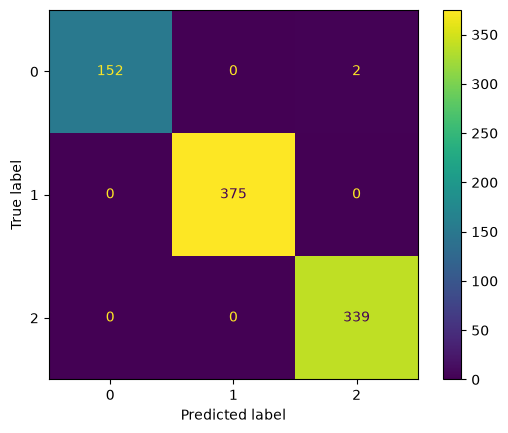

In [8]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()
plt.show()

In [10]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(X_train, y_train)

y_pred_rf = random_forest_model.predict(X_test)

accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", accuracy_rf)

Random Forest Accuracy: 0.9815668202764977


In [11]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.99      0.97      0.98       154
           1       0.98      0.99      0.99       375
           2       0.97      0.98      0.98       339

    accuracy                           0.98       868
   macro avg       0.98      0.98      0.98       868
weighted avg       0.98      0.98      0.98       868



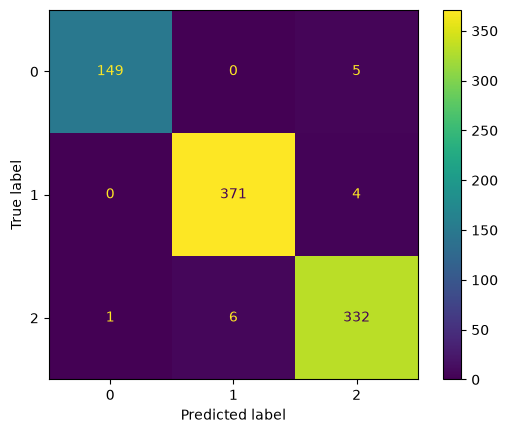

In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_rf = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf
)

disp.plot()
plt.show()

In [13]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    random_forest_model,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("Accuracy par fold :", cv_scores)
print("Accuracy moyenne :", cv_scores.mean())

Accuracy par fold : [0.98270893 0.9870317  0.98126801 0.98270893 0.97550432]
Accuracy moyenne : 0.9818443804034583


In [14]:
random_forest_model.feature_importances_

array([0.31637311, 0.35235363, 0.33127326])

In [21]:
new_customer = pd.DataFrame({
    "Recency": [10],
    "Frequency": [8],
    "Monetary": [5000]
})

new_customer_log = np.log1p(new_customer)

new_customer_scaled = scaler.transform(new_customer_log)

predicted_cluster = random_forest_model.predict(new_customer_scaled)

print("Predicted Cluster:", predicted_cluster)

Predicted Cluster: [0]


In [22]:
cluster_names = {
    0: "Clients VIP",
    1: "Clients Inactifs",
    2: "Clients Occasionnels"
}

In [23]:
predicted_cluster = random_forest_model.predict(new_customer_scaled)

predicted_segment = cluster_names[predicted_cluster[0]]

print("Cluster:", predicted_cluster[0])
print("Segment:", predicted_segment)

Cluster: 0
Segment: Clients VIP


In [25]:
cluster_names = {
    0: "Clients VIP",
    1: "Clients Inactifs",
    2: "Clients Occasionnels"
}

rfm["Segment"] = rfm["Cluster"].map(cluster_names)

In [29]:
import joblib

joblib.dump(
    random_forest_model,
    "../models/random_forest_model.joblib"
)

['../models/random_forest_model.joblib']

In [30]:
X_log = np.log1p(X)
X_scaled = scaler.fit_transform(X_log)

In [31]:
joblib.dump(
    scaler,
    "../models/scaler.joblib"
)

['../models/scaler.joblib']

In [32]:
import json

with open("../models/cluster_names.json", "w", encoding="utf-8") as f:
    json.dump(cluster_names, f, ensure_ascii=False, indent=4)

In [34]:
new_customer = pd.DataFrame({
    "Recency": [10],
    "Frequency": [8],
    "Monetary": [5000]
})

new_customer_log = np.log1p(new_customer)

new_customer_scaled = loaded_scaler.transform(
    new_customer_log
)

prediction = loaded_model.predict(
    new_customer_scaled
)

cluster = prediction[0]
segment = loaded_cluster_names[str(cluster)]

print("Cluster :", cluster)
print("Segment :", segment)

Cluster : 0
Segment : Clients VIP
